In [1]:

from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import statsmodels.tsa.api as smt

In [2]:
# аналогичным образом загружаем данные о пассажирах
ecg = pd.read_csv('data/calm_p.csv')

# неподходящий формат данных приводим к тому, с которым Pandas может работать

df = ecg.set_index('Time').sort_index()

### Скользящее среднее

In [3]:
df['MA_window_3'] = df['1'].rolling(window=3).mean()
df

,1,2,3,4,5,6,MA_window_3
Time,,,,,,,
10.000,1.313532,-0.367128,-0.293800,1.946667,1.873333,-0.330268,NaN
10.001,1.312748,-0.369088,-0.294584,1.947843,1.873333,-0.331836,NaN
10.002,1.312356,-0.370657,-0.294976,1.948627,1.872941,-0.332621,1.312879
10.003,1.311179,-0.372618,-0.294976,1.949804,1.872157,-0.333797,1.312094
10.004,1.310787,-0.374578,-0.295761,1.950980,1.872157,-0.334973,1.311441
...,...,...,...,...,...,...,...
59.995,1.357450,-0.084404,-0.099697,1.822745,1.838039,-0.091854,1.357058
59.996,1.357450,-0.083227,-0.098912,1.822353,1.838039,-0.091070,1.357319
59.997,1.357058,-0.082443,-0.097344,1.822353,1.837255,-0.089893,1.357319


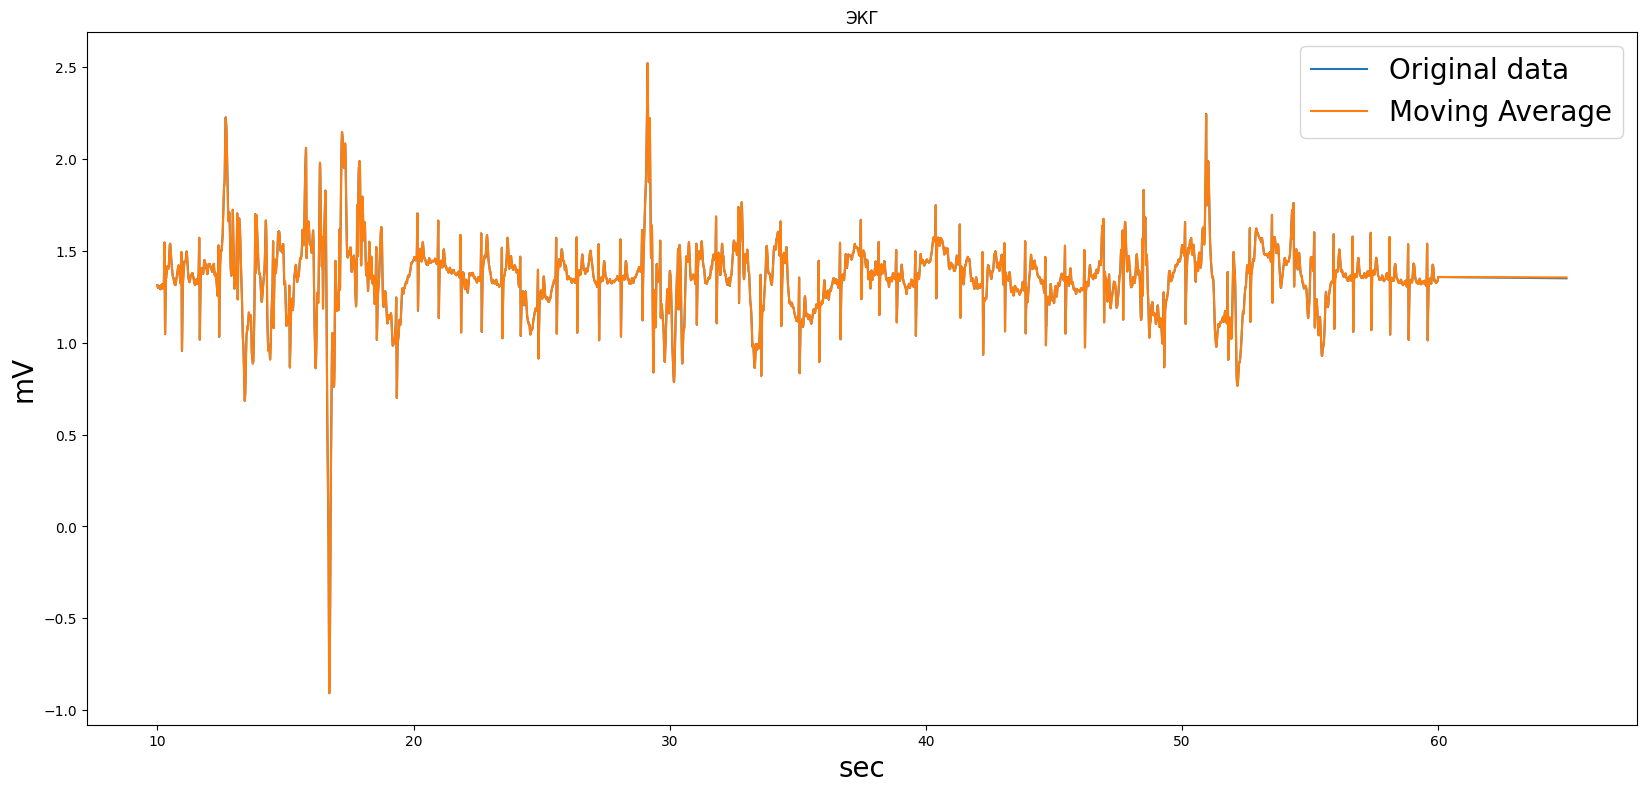

In [4]:
fig = plt.figure(figsize=(20, 9))
plt.plot(df['1'], label='Original data')
plt.plot(df['MA_window_3'], label='Moving Average')
plt.legend(fontsize="20")
plt.title('ЭКГ')
plt.ylabel('mV', fontsize="20")
plt.xlabel('sec', fontsize="20")
plt.show()

Можно поиграться с размерностью окна

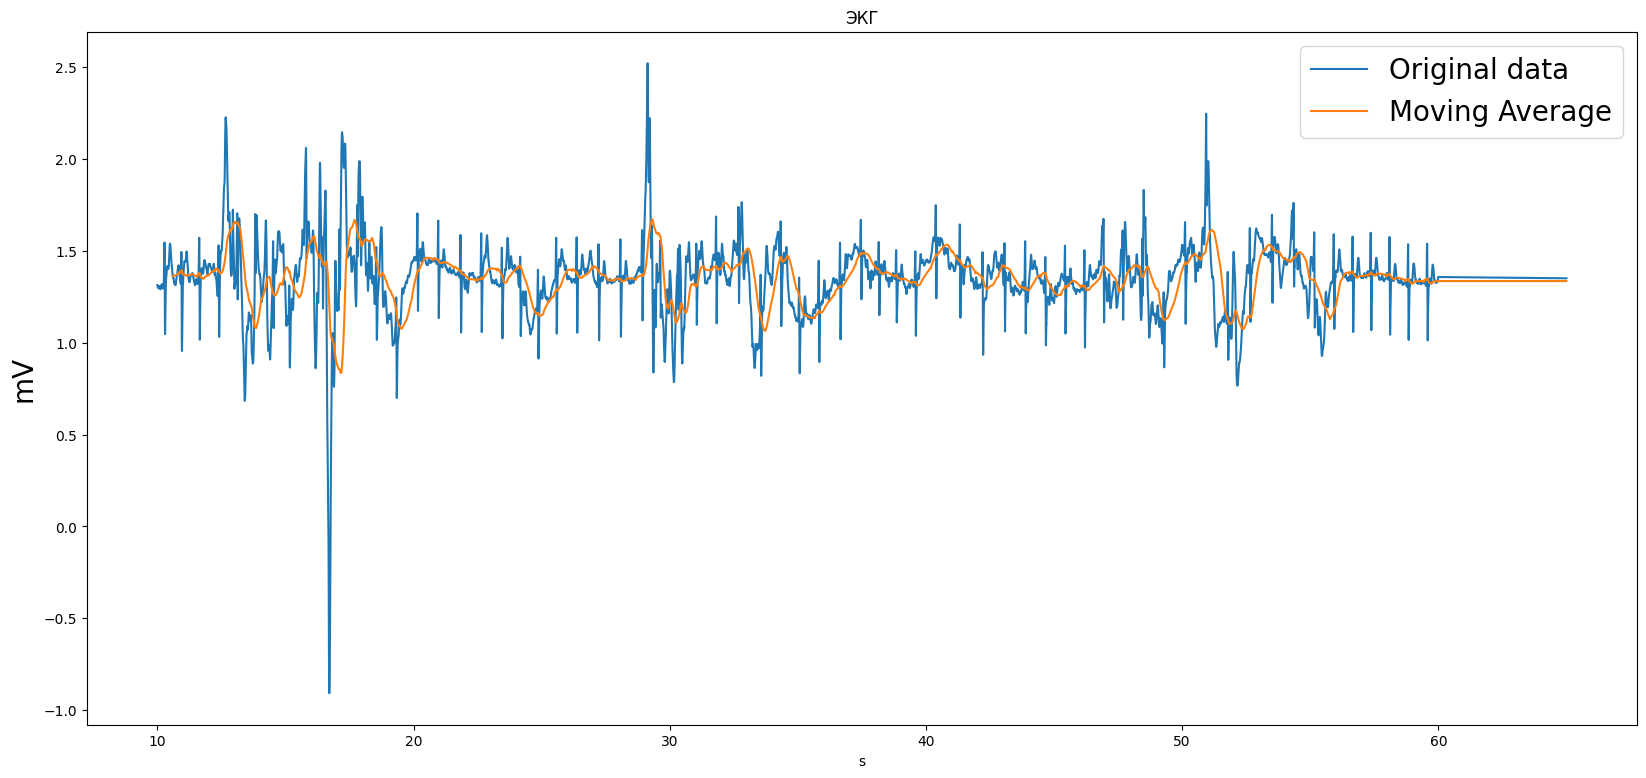

In [5]:
df['MA_window_6'] = df['1'].rolling(window=600).mean()
fig = plt.figure(figsize=(20, 9))
plt.plot(df['1'], label='Original data')
plt.plot(df['MA_window_6'], label='Moving Average')
plt.legend(fontsize="20")
plt.title('ЭКГ')
plt.ylabel('mV', fontsize="20")
plt.xlabel('s')
plt.show()


Давайте напишем функцию, которая поможет нам понять тенденцию и движения временного ряда. Мы хотим видеть на графике некоторую скользящую статистику, такую как:

M скользящее среднее: невзвешенное среднее предыдущих n данных (также называемое скользящим средним).

Полосы Боллинджера: верхняя полоса в k раз на n -периодное стандартное отклонение выше скользящей средней и нижняя полоса в k раз на стандартное отклонение N ниже.

In [6]:
'''
Отрисовка скользящего среднего по медиане для ts с 95% доверительным интервалом для стандартного отклонения.
:parameter
  :param ts: датасет
  :param window: кол-во семплов в окне - для скользящих средних
  :param plot_ma: bool - whether plot moving average
  :param plot_intervals: bool - whether plot upper and lower bounds
'''
def plot_ts(ts, plot_ma=True, plot_intervals=True, window=100,
            figsize=(15,5)):
    rolling_mean = ts.rolling(window=window).mean()
    rolling_std = ts.rolling(window=window).std()
    plt.figure(figsize=figsize)
    plt.title(ts.name)
    plt.plot(ts[window:], label='Реальные значения', color="black")
    if plot_ma:
        plt.plot(rolling_mean, 'g', label='MA'+str(window),
                 color="red")
    if plot_intervals:
        lower_bound = rolling_mean - (1.96 * rolling_std)
        upper_bound = rolling_mean + (1.96 * rolling_std)
    plt.fill_between(x=ts.index, y1=lower_bound, y2=upper_bound,
                     color='lightskyblue', alpha=0.4)
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

C:\Users\andyk\AppData\Local\Temp\ipykernel_16936\3736708662.py:15: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  plt.plot(ts[window:], label='Реальные значения', color="black")
C:\Users\andyk\AppData\Local\Temp\ipykernel_16936\3736708662.py:17: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g" (-> color=(0.0, 0.5, 0.0, 1)). The keyword argument will take precedence.
  plt.plot(rolling_mean, 'g', label='MA'+str(window),


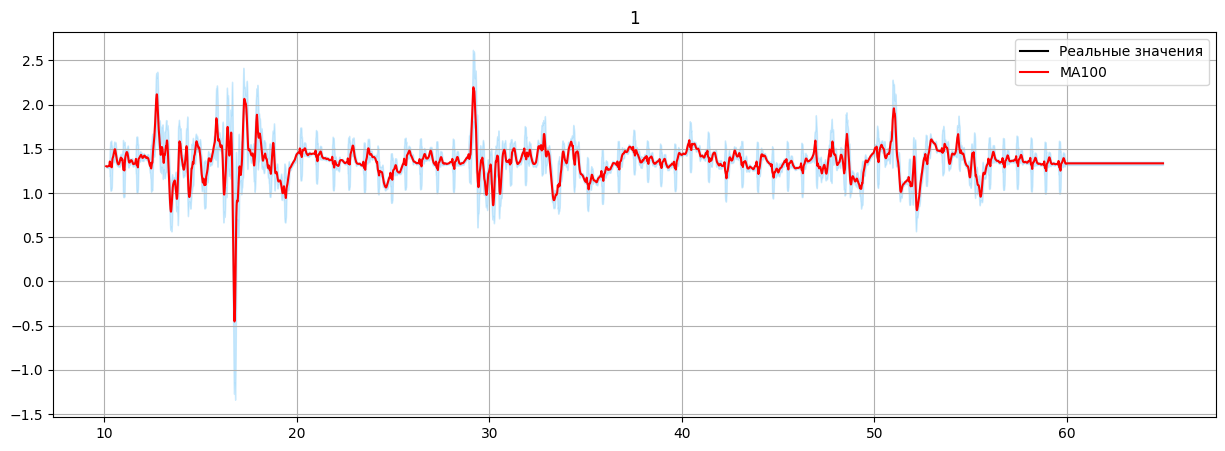

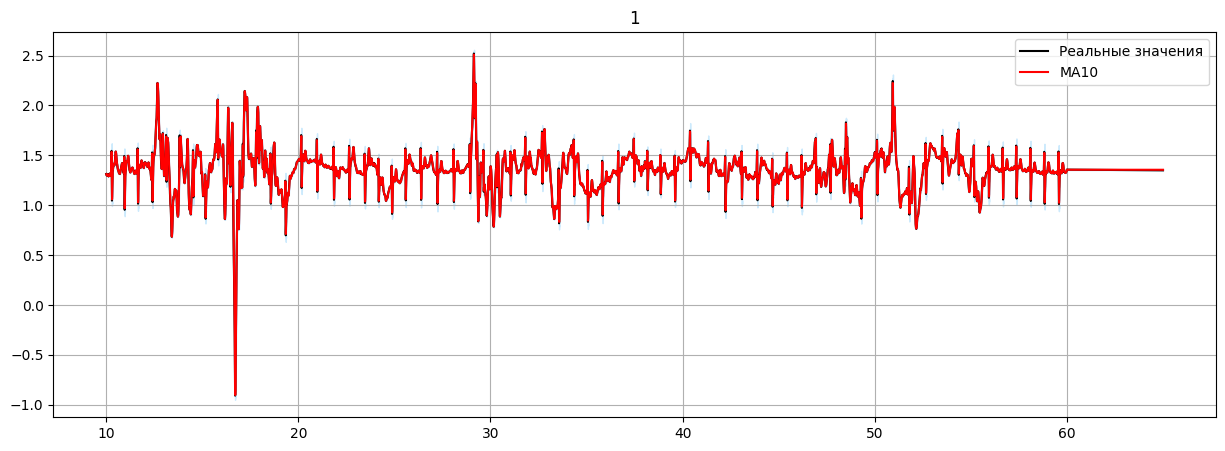

In [7]:
plot_ts(df["1"], window=100)
plot_ts(df["1"], window=10)

### ARMA

In [8]:
from statsmodels.tsa.arima.model import ARIMA

## Предсказание ряда на основе предыдущих значений

### ARIMA  

Модель авторегрессии скользящего среднего и систематический подход к её построению предназначена для анализа стационарных временных рядов на основе оценки линейной зависимости прогнозируемых значений от исторических.

Для использования модели временной ряд должен быть стационарным, т.е. его среднее и дисперсия должны быть постоянны.

Модель Бокса-Дженкинса предполагает, что временной ряд содержит три составляющие: авторегресионную, интегрированную и скользящее среднее, которые в модели обозначены $p$, $d$ и $q$ соответственно:

* Величина $p$ называется порядком авторегрессии. Она позволяет ответить на вопрос, будет ли очередной элемент ряда близок к значению $X$, если к нему были близки $p$ предыдущих значений.
* Величину $d$ называют порядком интегрирования. Она показывает, насколько элемент ряда близок по значению к $d$ предыдущим значениям, если разность между ними минимальна.

* Параметр $q$— порядок скользящего среднего. Позволяет установить погрешность модели как линейную комбинацию наблюдавшихся ранее значений ошибок.

Авторегрессия — это составляющая модели временного ряда, в которой его прогнозируемое значение может быть выражено в виде линейной комбинации исторических значений этого же ряда и случайной ошибки.

Обычно модель упоминается, как ARIMA$(p,d,q)$, где $p$, $d$ и $q$ — целые неотрицательные числа, характеризующие порядок для частей модели (соответственно авторегрессионной, интегрированной и скользящего среднего).

Для временного ряда $X(t)$ модель может быть записана в виде:

$$(\delta^dX_t)=\sum^p_{t=1}a_t(\delta^dX_{t-1}) + \epsilon_t + \sum^q_{j=1}b_j(\delta^d\epsilon_{t-j})$$

где

* $\delta^d$ — оператор разности порядка $d$ (последовательное взятие $d$ раз разностей первого порядка — сначала от самого ряда, затем от полученных разностей первого порядка, затем от второго порядка и т. д.);
* $a_t$— коэффициенты авторегрессионной части модели, $\epsilon_t$— значения ошибки (полагаются независимыми одинаково распределёнными случайными величинами из нормального распределения с нулевым средним);
* $b_j$ — коэффициенты скользящего среднего.

Модель Бокса-Дженкинса широко применяются при прогнозировании временных рядов. Основная задача при этом заключается в оценке параметров модели. Методология построения ARIMA-модели исследуемого временного ряда включает следующие основные этапы:

* построение пробной модели;
* оценивание параметров модели и проверка адекватности модели;
* использование модели для прогнозирования.

Чтобы построить модель ARMA, мы можем использовать функцию ARIMA (которая будет
объяснена в следующем разделе) в statsmodels.tsa.arima.model и указать
гиперпараметр — order(p, d, q). Когда d = 0, он работает как модель ARMA.

In [9]:
arma_model = ARIMA(df['1'], order=(5,0,3))
arma_model_fit = arma_model.fit()

C:\Users\andyk\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\andyk\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\andyk\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, 

In [10]:
print(arma_model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      1   No. Observations:                50000
Model:                 ARIMA(5, 0, 3)   Log Likelihood              232403.827
Date:                Fri, 05 Jun 2026   AIC                        -464787.654
Time:                        18:07:46   BIC                        -464699.457
Sample:                             0   HQIC                       -464760.027
                              - 50000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.3528      0.004    304.324      0.000       1.344       1.362
ar.L1         -0.4039      0.012    -33.911      0.000      -0.427      -0.381
ar.L2          1.4033      0.007    214.693      0.0

In [11]:
X = df['1'].values
size = int(len(X) * 0.66)
train, test = X[0:size], X[size:len(X)]
history = [x for x in train]
arma_predictions = list()
# walk-forward validation
for t in range(len(test)):
    model = ARIMA(history, order=(5,1,0))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    arma_predictions.append(yhat)
    obs = test[t]
    history.append(obs)

KeyboardInterrupt: 

In [12]:
print(len(train))
print(len(test))
print(len(arma_predictions))

33000
17000
87


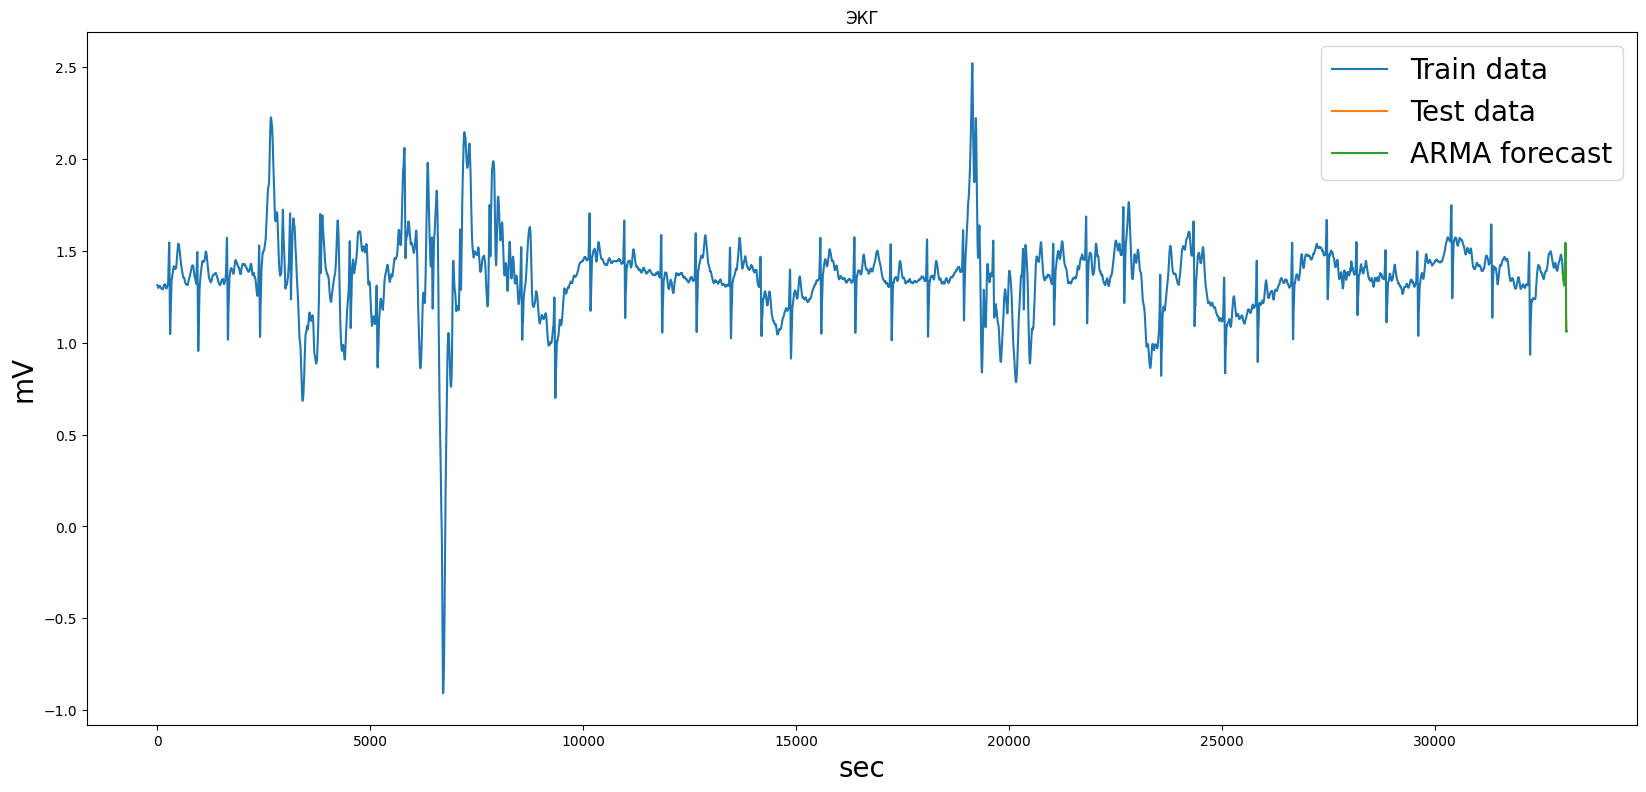

In [13]:
fig = plt.figure(figsize=(20, 9))
dur = len(arma_predictions)

plt.plot([i for i in range(0, size)], train, label='Train data')
plt.plot([i for i in range(size - 1, size - 1 + dur)], test[:dur], label='Test data')
plt.plot([i for i in range(size - 1, size - 1 + dur)], arma_predictions, label='ARMA forecast')
plt.legend(fontsize="20")
plt.title('ЭКГ')
plt.ylabel('mV', fontsize="20")
plt.xlabel('sec', fontsize="20")
plt.show()

In [14]:
# аналогичным образом загружаем данные о пассажирах
passengers = pd.read_csv('data/passengers.csv')
# неподходящий формат данных приводим к тому, с которым Pandas может работать
passengers['Month'] = pd.to_datetime(passengers['Month'])
# также устанавливаем индекс и сортируем
pdf = passengers.set_index('Month').sort_index()

In [15]:
passengers

,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


In [16]:
p_arma_model = ARIMA(pdf['Passengers'], order=(5,0,3))
p_arma_model_fit = p_arma_model.fit()

C:\Users\andyk\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\andyk\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\andyk\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\andyk\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\Local

In [17]:
from IPython.display import clear_output
%matplotlib inline

def live_plot(data_dict, figsize=(7,5), title=''):
    clear_output(wait=True)
    plt.figure(figsize=figsize)
    for label,data in data_dict.items():
        plt.plot(data, label=label)
    plt.title(title)
    plt.grid(True)
    plt.xlabel('epoch')
    plt.legend(loc='center left')
    plt.show()

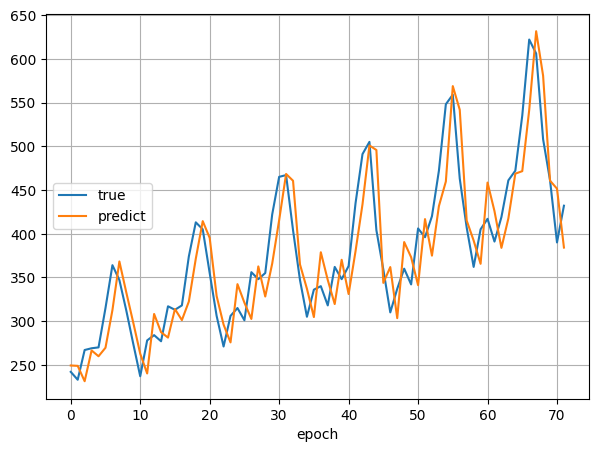

In [18]:
series = pdf["Passengers"]
#series = df['1']

size = int(series.shape[0] * 0.5)
train, test = series[:size], series[size:len(series)]
history = [x for x in train.values]
predictions = []

val = {"true":[], "predict":[]}
for t in test.values:
    model = ARIMA(history, order=(5,1,0)).fit()
    output = model.forecast()
    yhat = output[0]
    predictions.append(yhat)
    val["predict"].append(yhat)
    val["true"].append(t)
    history.append(t)
    live_plot(val)

In [19]:
X = pdf['Passengers'].values
size = int(len(X) * 0.66)
train, test = X[0:size], X[size:len(X)]
history = [x for x in train]
arma_predictions = list()
# walk-forward validation
for t in range(len(test)):
    model = ARIMA(history, order=(5,1,0))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    arma_predictions.append(yhat)
    obs = test[t]
    history.append(obs)

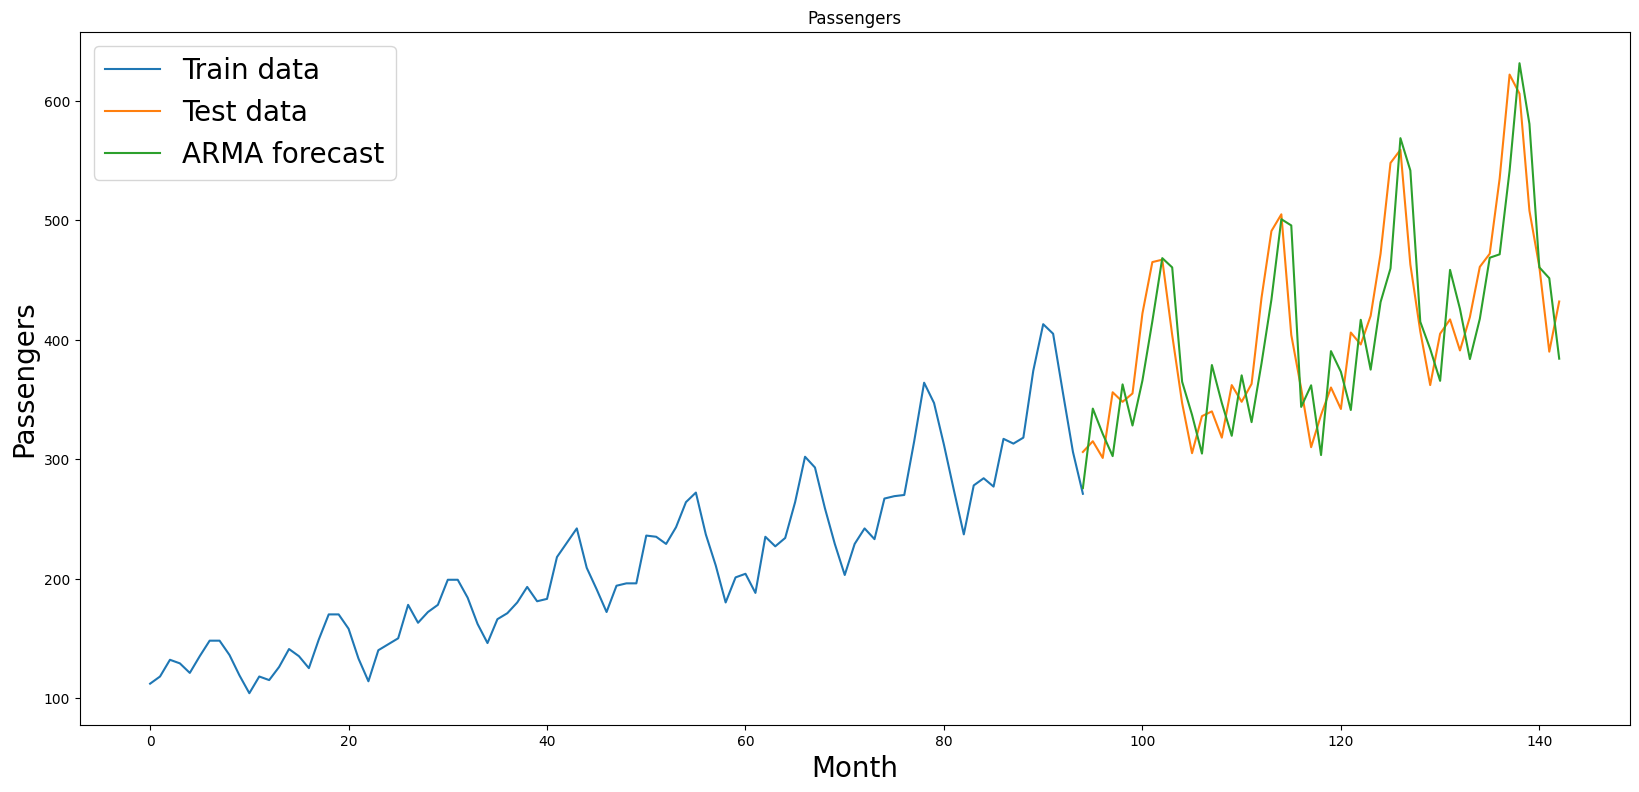

In [20]:
fig = plt.figure(figsize=(20, 9))
dur = len(arma_predictions)

plt.plot([i for i in range(0, size)], train, label='Train data')
plt.plot([i for i in range(size - 1, size - 1 + dur)], test[:dur], label='Test data')
plt.plot([i for i in range(size - 1, size - 1 + dur)], arma_predictions, label='ARMA forecast')
plt.legend(fontsize="20")
plt.title('Passengers')
plt.ylabel('Passengers', fontsize="20")
plt.xlabel('Month', fontsize="20")
plt.show()

### ARIMA

In [21]:
arima_model = ARIMA(pdf['Passengers'], order=(10,2,10))
arima_model_fit = arima_model.fit()

C:\Users\andyk\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\andyk\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\andyk\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\andyk\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\Local

In [22]:
print(arima_model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  144
Model:               ARIMA(10, 2, 10)   Log Likelihood                -555.051
Date:                Fri, 05 Jun 2026   AIC                           1152.102
Time:                        18:12:23   BIC                           1214.174
Sample:                    01-01-1949   HQIC                          1177.325
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0738      0.062      1.196      0.232      -0.047       0.195
ar.L2         -1.0001      0.082    -12.219      0.000      -1.161      -0.840
ar.L3          0.0154      0.094      0.164      0.8

Полезным может быть получение линейного графика остаточных ошибок, что позволяет предположить, что некоторая информация о тенденциях все еще может быть не учтена моделью.

<Axes: xlabel='Month'>

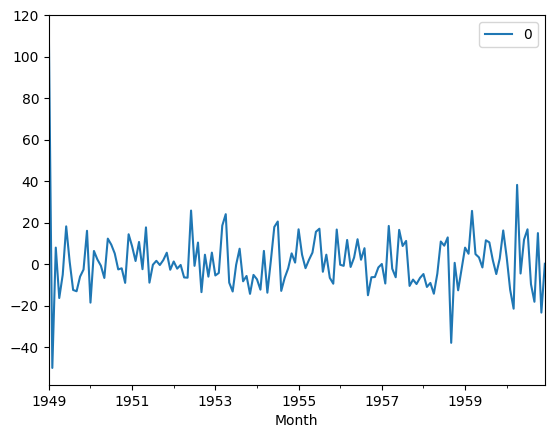

In [23]:
arima_residuals = pd.DataFrame(arima_model_fit.resid)
arima_residuals.plot()

Осуществляем предсказание

In [24]:
# forecast предсказывает только следующее значение
output = arima_model_fit.forecast()

In [25]:
X = pdf['Passengers'].values
size = int(len(X) * 0.66)
train, test = X[0:size], X[size:len(X)]
history = [x for x in train]
arima_predictions = list()
# walk-forward validation
for t in range(len(test)):
    arima_model = ARIMA(history, order=(10,2,5))
    arima_model_fit = arima_model.fit()
    output = arima_model_fit.forecast()
    yhat = output[0]
    arima_predictions.append(yhat)
    obs = test[t]
    history.append(obs)

C:\Users\andyk\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\andyk\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\andyk\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:

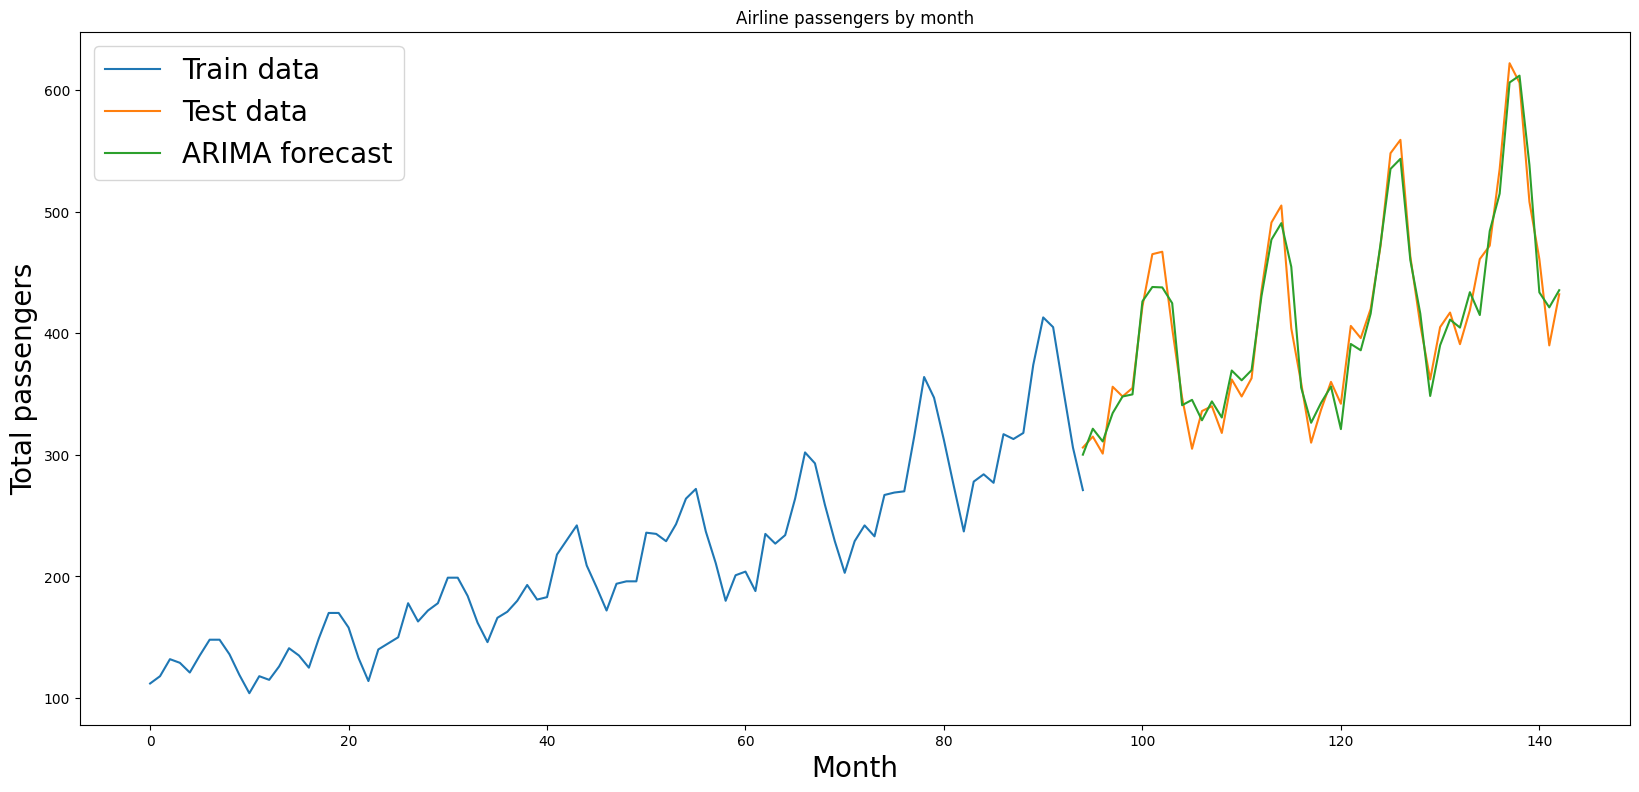

In [26]:
fig = plt.figure(figsize=(20, 9))
plt.plot([i for i in range(0, size)], train, label='Train data')
plt.plot([i for i in range(size - 1, len(X) - 1)], test, label='Test data')
plt.plot([i for i in range(size - 1, len(X) - 1)], arima_predictions, label='ARIMA forecast')
plt.legend(fontsize="20")
plt.title('Airline passengers by month')
plt.ylabel('Total passengers', fontsize="20")
plt.xlabel('Month', fontsize="20")
plt.show()

Сравним значения ARMA и ARIMA

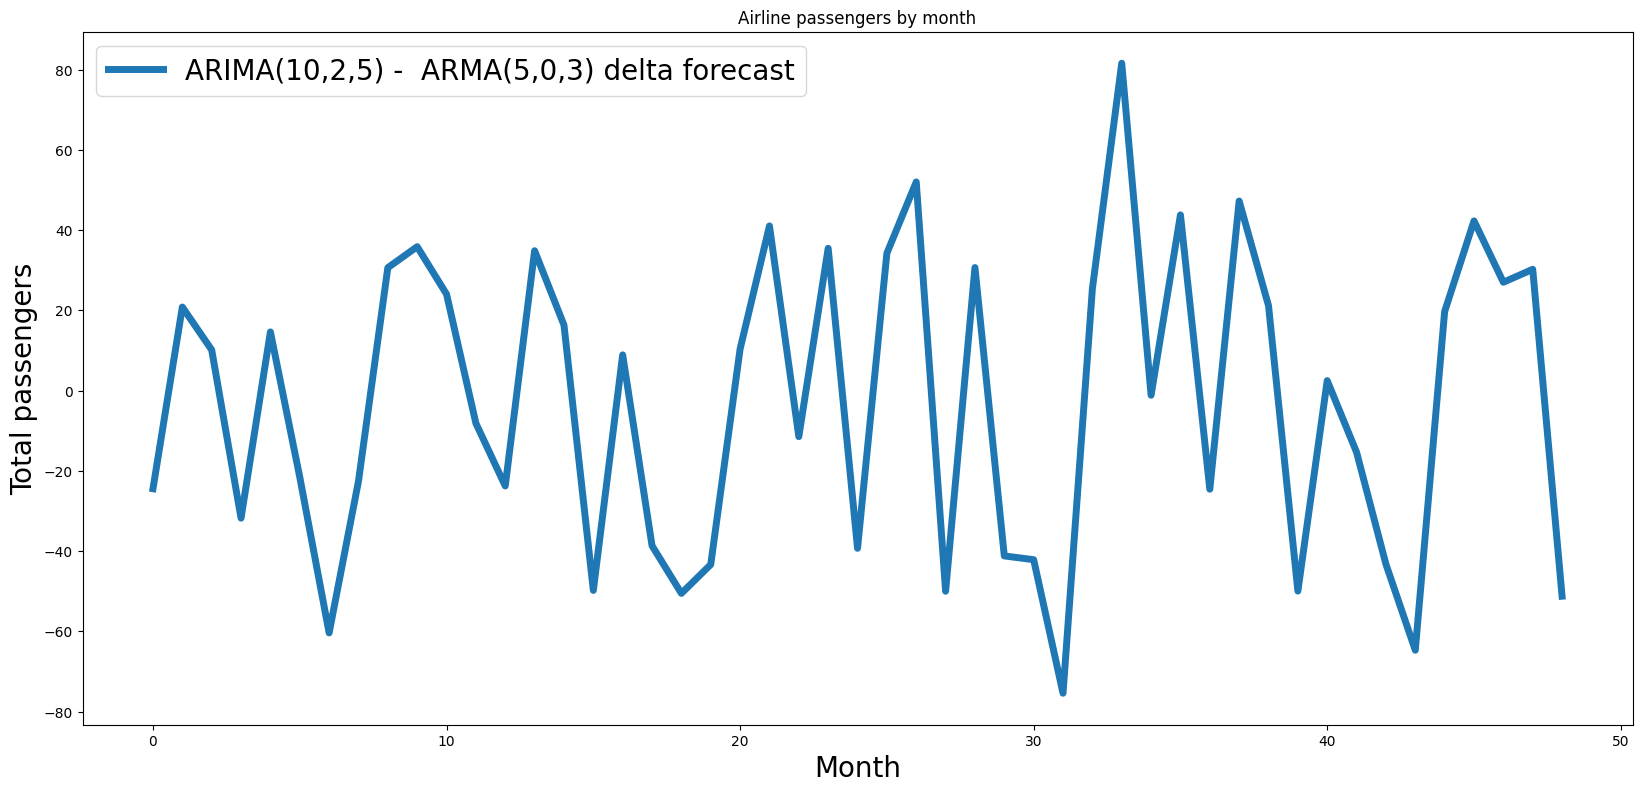

In [27]:
fig = plt.figure(figsize=(20, 9))

delta = []

for i in range(len(arima_predictions)):
    delta.append(arma_predictions[i] - arima_predictions[i])

plt.plot(delta, label='ARIMA(10,2,5) -  ARMA(5,0,3) delta forecast', linewidth=5)
plt.legend(fontsize="20")
plt.title('Airline passengers by month')
plt.ylabel('Total passengers', fontsize="20")
plt.xlabel('Month', fontsize="20")
plt.show()

### Работа с пропусками данных

#### **Задание №1:**


Заполнените пропущенные значения:
* средним и медианой​
* предыдущим и последующим значениями​
* скользящим средним и медианой​

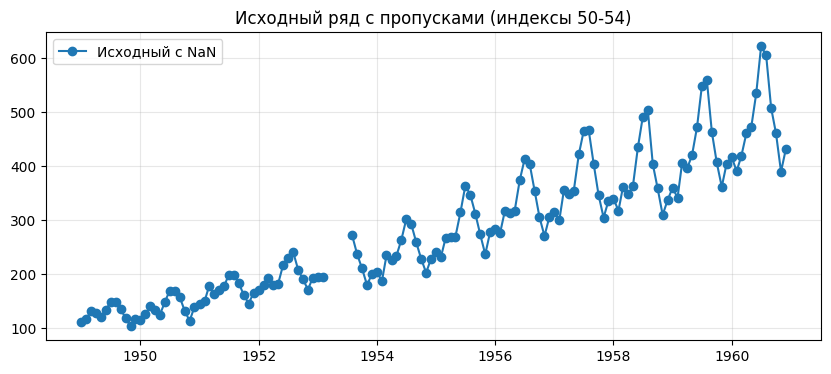

C:\Users\andyk\AppData\Local\Temp\ipykernel_16936\2769686009.py:36: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  o_df_ffill['Passengers'] = o_df_ffill['Passengers'].fillna(method='ffill')
C:\Users\andyk\AppData\Local\Temp\ipykernel_16936\2769686009.py:39: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  o_df_bfill['Passengers'] = o_df_bfill['Passengers'].fillna(method='bfill')


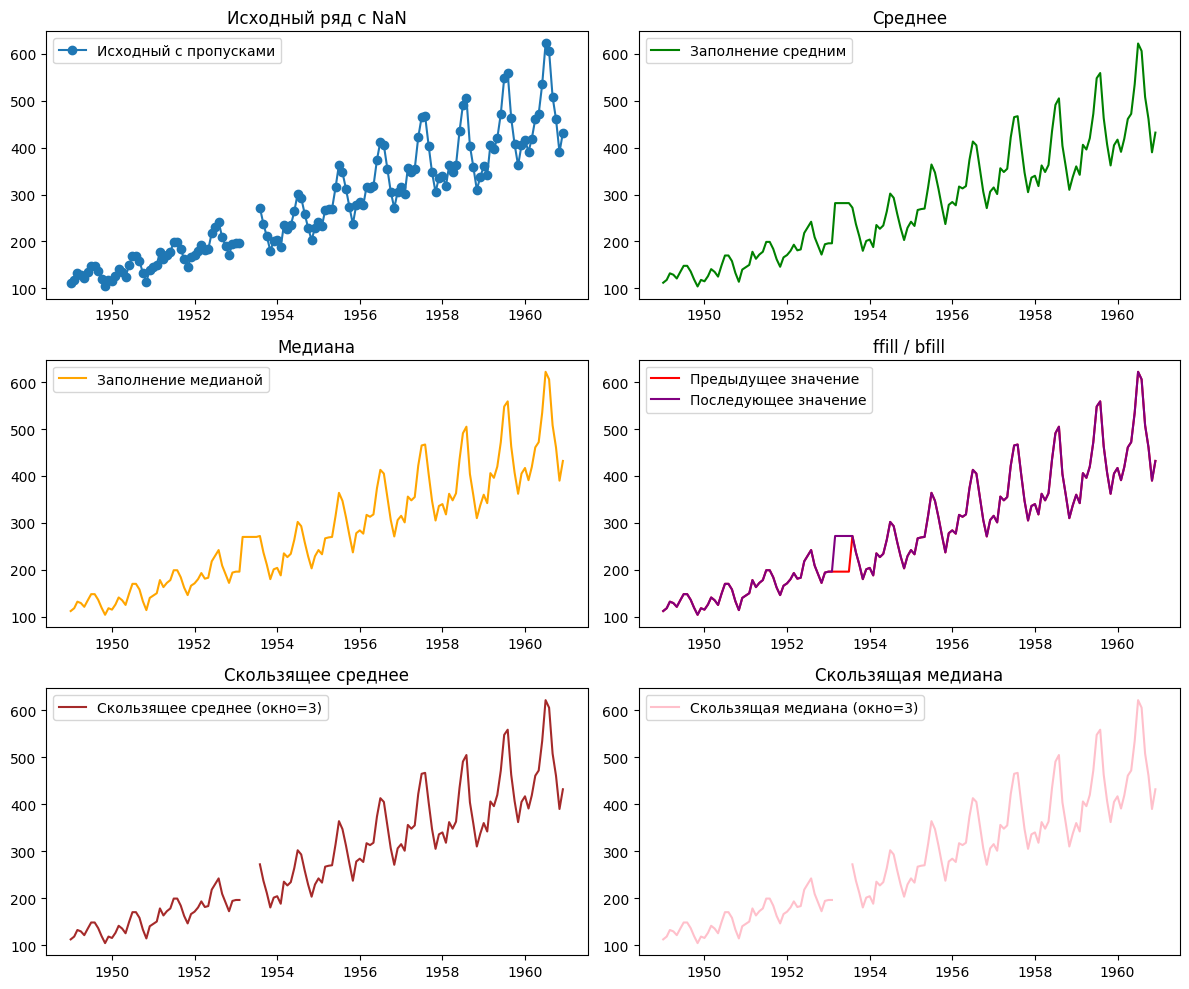

Заполненные значения для целочисленных позиций 50-54:
Исходные NaN: [nan nan nan nan nan]
Среднее:      [281.69784173 281.69784173 281.69784173 281.69784173 281.69784173]
Медиана:      [270. 270. 270. 270. 270.]
ffill:        [196. 196. 196. 196. 196.]
bfill:        [272. 272. 272. 272. 272.]
roll_mean:    [nan nan nan nan nan]
roll_median:  [nan nan nan nan nan]


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

if 'pdf' not in globals():
    dates = pd.date_range('1949-01-01', periods=144, freq='M')
    np.random.seed(42)
    passengers = 100 + np.cumsum(np.random.normal(0, 5, 144)) + 20 * np.sin(2 * np.pi * np.arange(144) / 12)
    pdf = pd.DataFrame({'Passengers': passengers}, index=dates)

# Создаём копию и вносим пропуски в позициях 50–54 (по целочисленному индексу)
o_df = pdf.copy()
# Устанавливаем NaN в указанных позициях (по iloc)
o_df.iloc[50:55, o_df.columns.get_loc('Passengers')] = np.nan

# Визуализируем исходный ряд с пропусками
plt.figure(figsize=(10,4))
plt.plot(o_df.index, o_df['Passengers'], label='Исходный с NaN', marker='o')
plt.legend()
plt.title('Исходный ряд с пропусками (индексы 50-54)')
plt.grid(alpha=0.3)
plt.show()

# 1. Заполнение средним и медианой
mean_val = o_df['Passengers'].mean()
median_val = o_df['Passengers'].median()

o_df_mean = o_df.copy()
o_df_mean['Passengers'] = o_df_mean['Passengers'].fillna(mean_val)

o_df_median = o_df.copy()
o_df_median['Passengers'] = o_df_median['Passengers'].fillna(median_val)

# 2. Заполнение предыдущим и последующим значениями
o_df_ffill = o_df.copy()
o_df_ffill['Passengers'] = o_df_ffill['Passengers'].fillna(method='ffill')

o_df_bfill = o_df.copy()
o_df_bfill['Passengers'] = o_df_bfill['Passengers'].fillna(method='bfill')

# 3. Заполнение скользящим средним и скользящей медианой (окно = 3)
window = 3
rolling_mean = o_df['Passengers'].rolling(window=window, center=True).mean()
rolling_median = o_df['Passengers'].rolling(window=window, center=True).median()

o_df_rollmean = o_df.copy()
o_df_rollmean['Passengers'] = o_df_rollmean['Passengers'].fillna(rolling_mean)

o_df_rollmedian = o_df.copy()
o_df_rollmedian['Passengers'] = o_df_rollmedian['Passengers'].fillna(rolling_median)

# Визуализация всех методов
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes[0,0].plot(o_df.index, o_df['Passengers'], label='Исходный с пропусками', marker='o')
axes[0,0].set_title('Исходный ряд с NaN')
axes[0,0].legend()

axes[0,1].plot(o_df_mean.index, o_df_mean['Passengers'], label='Заполнение средним', color='green')
axes[0,1].set_title('Среднее')
axes[0,1].legend()

axes[1,0].plot(o_df_median.index, o_df_median['Passengers'], label='Заполнение медианой', color='orange')
axes[1,0].set_title('Медиана')
axes[1,0].legend()

axes[1,1].plot(o_df_ffill.index, o_df_ffill['Passengers'], label='Предыдущее значение', color='red')
axes[1,1].plot(o_df_bfill.index, o_df_bfill['Passengers'], label='Последующее значение', color='purple')
axes[1,1].set_title('ffill / bfill')
axes[1,1].legend()

axes[2,0].plot(o_df_rollmean.index, o_df_rollmean['Passengers'], label='Скользящее среднее (окно=3)', color='brown')
axes[2,0].set_title('Скользящее среднее')
axes[2,0].legend()

axes[2,1].plot(o_df_rollmedian.index, o_df_rollmedian['Passengers'], label='Скользящая медиана (окно=3)', color='pink')
axes[2,1].set_title('Скользящая медиана')
axes[2,1].legend()

plt.tight_layout()
plt.show()

# Печать заполненных значений для пропущенных позиций (по iloc)
print("Заполненные значения для целочисленных позиций 50-54:")
print("Исходные NaN:", o_df.iloc[50:55, o_df.columns.get_loc('Passengers')].values)
print("Среднее:     ", o_df_mean.iloc[50:55, o_df_mean.columns.get_loc('Passengers')].values)
print("Медиана:     ", o_df_median.iloc[50:55, o_df_median.columns.get_loc('Passengers')].values)
print("ffill:       ", o_df_ffill.iloc[50:55, o_df_ffill.columns.get_loc('Passengers')].values)
print("bfill:       ", o_df_bfill.iloc[50:55, o_df_bfill.columns.get_loc('Passengers')].values)
print("roll_mean:   ", o_df_rollmean.iloc[50:55, o_df_rollmean.columns.get_loc('Passengers')].values)
print("roll_median: ", o_df_rollmedian.iloc[50:55, o_df_rollmedian.columns.get_loc('Passengers')].values)

C:\Users\andyk\AppData\Local\Temp\ipykernel_16936\393590556.py:21: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  o_df_ffill['Passengers'] = o_df_ffill['Passengers'].fillna(method='ffill')
C:\Users\andyk\AppData\Local\Temp\ipykernel_16936\393590556.py:24: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  o_df_bfill['Passengers'] = o_df_bfill['Passengers'].fillna(method='bfill')


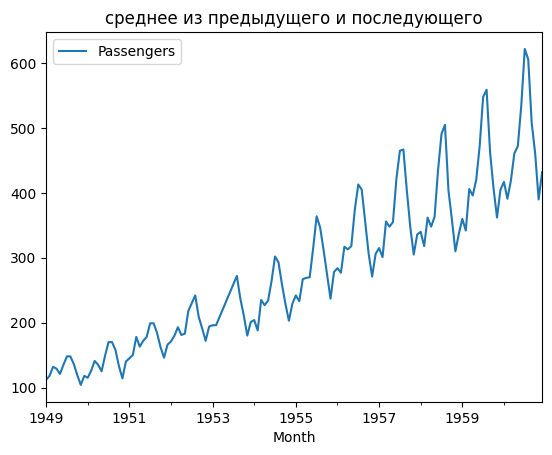

Заполненные значения для позиций 50-54 (индексы по порядку):
Исходные NaN:       [nan nan nan nan nan]
Среднее:            [281.69784173 281.69784173 281.69784173 281.69784173 281.69784173]
Медиана:            [270. 270. 270. 270. 270.]
ffill (предыдущее): [196. 196. 196. 196. 196.]
bfill (последующее): [272. 272. 272. 272. 272.]
Скользящее среднее:  [nan nan nan nan nan]
Скользящая медиана:  [nan nan nan nan nan]
Среднее из пред/посл (интерполяция): [208.66666667 221.33333333 234.         246.66666667 259.33333333]


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Создаём копию и вносим пропуски в позициях 50:55 (по целочисленным индексам)
o_df = pdf.copy()
o_df.iloc[50:55, o_df.columns.get_loc('Passengers')] = np.nan

# 1. Заполнение средним и медианой
mean_val = o_df['Passengers'].mean()
median_val = o_df['Passengers'].median()

o_df_mean = o_df.copy()
o_df_mean['Passengers'] = o_df_mean['Passengers'].fillna(mean_val)

o_df_median = o_df.copy()
o_df_median['Passengers'] = o_df_median['Passengers'].fillna(median_val)

# 2. Заполнение предыдущим и последующим значениями
o_df_ffill = o_df.copy()
o_df_ffill['Passengers'] = o_df_ffill['Passengers'].fillna(method='ffill')

o_df_bfill = o_df.copy()
o_df_bfill['Passengers'] = o_df_bfill['Passengers'].fillna(method='bfill')

# 3. Заполнение скользящим средним и скользящей медианой (окно = 3)
window = 3
rolling_mean = o_df['Passengers'].rolling(window=window, center=True).mean()
rolling_median = o_df['Passengers'].rolling(window=window, center=True).median()

o_df_rollmean = o_df.copy()
o_df_rollmean['Passengers'] = o_df_rollmean['Passengers'].fillna(rolling_mean)

o_df_rollmedian = o_df.copy()
o_df_rollmedian['Passengers'] = o_df_rollmedian['Passengers'].fillna(rolling_median)

# 4. Заполнение средним из предыдущего и последующего (линейная интерполяция)
o_df_interp = o_df.copy()
o_df_interp['Passengers'] = o_df_interp['Passengers'].interpolate(method='linear')

# График для метода "среднее из предыдущего и последующего"
o_df_interp.plot(title='среднее из предыдущего и последующего')
plt.show()

# Дополнительно: вывод всех заполненных значений для проверки
print("Заполненные значения для позиций 50-54 (индексы по порядку):")
print("Исходные NaN:      ", o_df.iloc[50:55, o_df.columns.get_loc('Passengers')].values)
print("Среднее:           ", o_df_mean.iloc[50:55, o_df_mean.columns.get_loc('Passengers')].values)
print("Медиана:           ", o_df_median.iloc[50:55, o_df_median.columns.get_loc('Passengers')].values)
print("ffill (предыдущее):", o_df_ffill.iloc[50:55, o_df_ffill.columns.get_loc('Passengers')].values)
print("bfill (последующее):", o_df_bfill.iloc[50:55, o_df_bfill.columns.get_loc('Passengers')].values)
print("Скользящее среднее: ", o_df_rollmean.iloc[50:55, o_df_rollmean.columns.get_loc('Passengers')].values)
print("Скользящая медиана: ", o_df_rollmedian.iloc[50:55, o_df_rollmedian.columns.get_loc('Passengers')].values)
print("Среднее из пред/посл (интерполяция):", o_df_interp.iloc[50:55, o_df_interp.columns.get_loc('Passengers')].values)

Заполнение предыдущим и последующим значениями​

C:\Users\andyk\AppData\Local\Temp\ipykernel_16936\2055037615.py:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  o_df_bfill['Passengers'] = o_df_bfill['Passengers'].fillna(method='bfill')


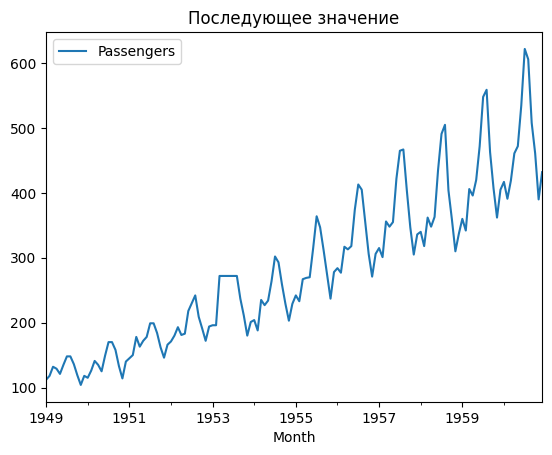

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Создаём копию и вносим пропуски в позициях 50:55
o_df = pdf.copy()
o_df.iloc[50:55, o_df.columns.get_loc('Passengers')] = np.nan

# Заполнение пропусков последующим значением (bfill)
o_df_bfill = o_df.copy()
o_df_bfill['Passengers'] = o_df_bfill['Passengers'].fillna(method='bfill')

# Построение графика
o_df_bfill.plot(title='Последующее значение')
plt.show()

Заполнение скользящим средним и медианой​

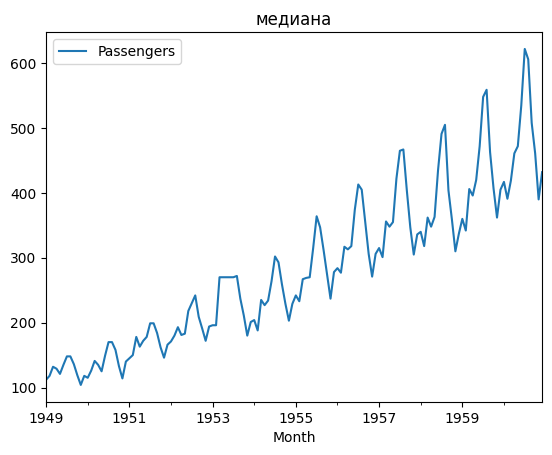

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Создаём копию и вносим пропуски в позициях 50:55
o_df = pdf.copy()
o_df.iloc[50:55, o_df.columns.get_loc('Passengers')] = np.nan

# Заполнение пропусков медианой
median_val = o_df['Passengers'].median()
o_df_median = o_df.copy()
o_df_median['Passengers'] = o_df_median['Passengers'].fillna(median_val)

# Построение графика
o_df_median.plot(title='медиана')
plt.show()

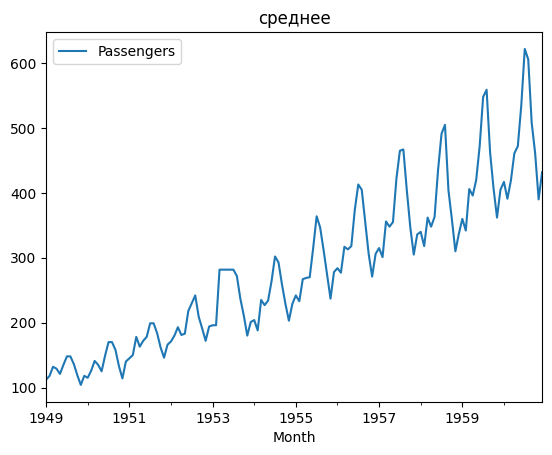

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Создаём копию и вносим пропуски в позициях 50:55
o_df = pdf.copy()
o_df.iloc[50:55, o_df.columns.get_loc('Passengers')] = np.nan

# Заполнение пропусков средним значением
mean_val = o_df['Passengers'].mean()
o_df_mean = o_df.copy()
o_df_mean['Passengers'] = o_df_mean['Passengers'].fillna(mean_val)

# Построение графика
o_df_mean.plot(title='среднее')
plt.show()

Интерполяция

C:\Users\andyk\AppData\Local\Temp\ipykernel_16936\3717442952.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  o_df["Passengers"][50:55] = np.nan


<Axes: title={'center': 'zero'}, xlabel='Month'>

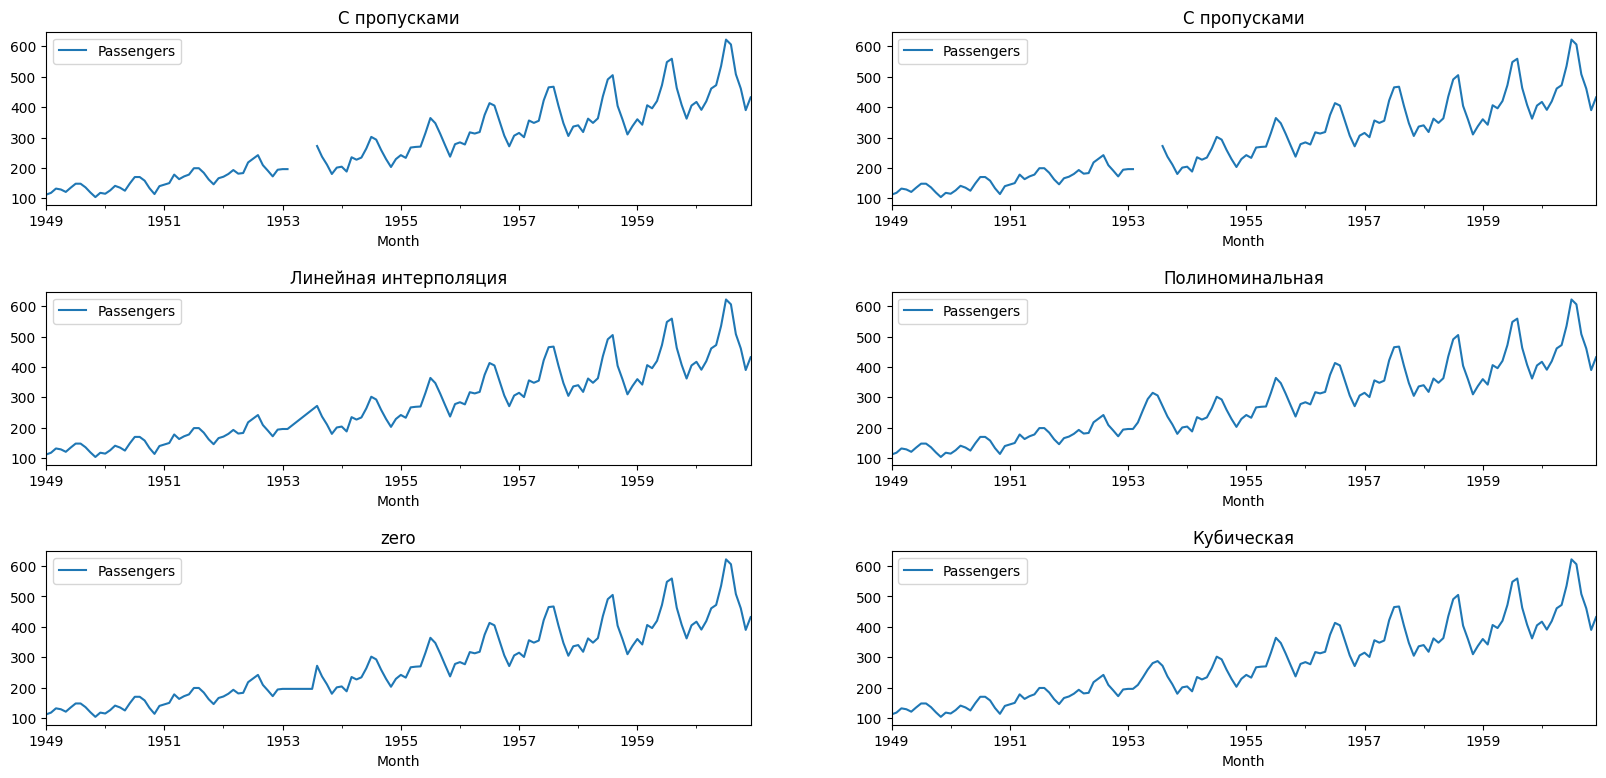

In [35]:
o_df["Passengers"][50:55] = np.nan

lin_df = o_df.interpolate(method="linear")

cub_df = o_df.interpolate(method="cubic")

pol_df = o_df.interpolate(method="polynomial", order=5)

zero_df = o_df.interpolate(method="zero")


fig = plt.figure(figsize=(20, 9))
layout = (3, 2)
plt.subplots_adjust(wspace=0.2, hspace=0.5)

original_ax = plt.subplot2grid(layout, (0, 0))
lin_ax = plt.subplot2grid(layout, (1, 0))
cub_ax = plt.subplot2grid(layout, (2, 1))

pol_ax = plt.subplot2grid(layout, (1, 1))
zero_ax = plt.subplot2grid(layout, (2, 0))
 
o_df.plot(title="С пропусками", ax = original_ax)  
o_df.plot(title="С пропусками", ax = plt.subplot2grid(layout, (0, 1)))  
lin_df.plot(title="Линейная интерполяция", ax = lin_ax) 
cub_df.plot(title="Кубическая", ax = cub_ax) 
pol_df.plot(title="Полиноминальная", ax = pol_ax) 
zero_df.plot(title="zero", ax=zero_ax)


### Работа с выбросами

In [36]:
import seaborn as sns

<Axes: >

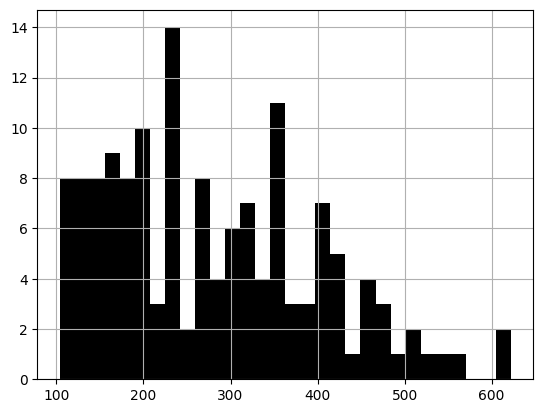

In [37]:
pdf["Passengers"].hist(bins=30, color="black")

<Axes: >

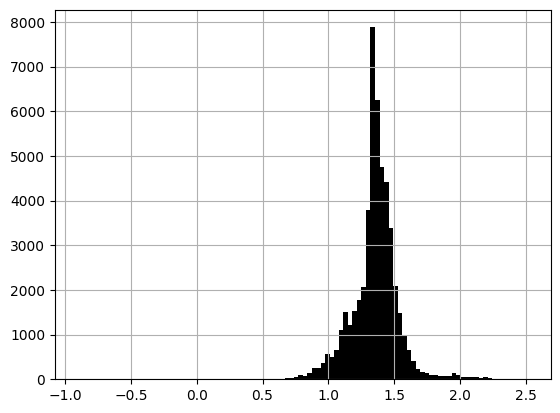

In [38]:
ecg["1"].hist(bins=100, color="black",)

Text(0.5, 1.0, 'Пассажиры')

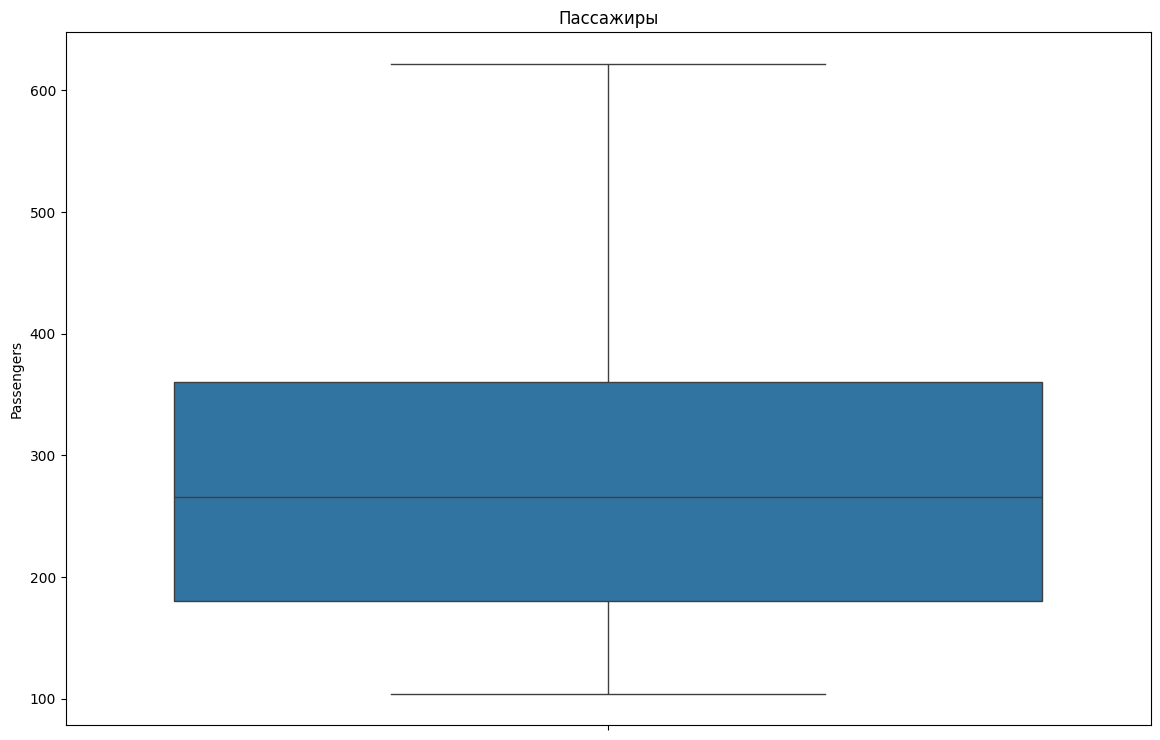

In [39]:
fig = plt.figure(figsize=(14, 9))
 
sns.boxplot(pdf.Passengers).set_title('Пассажиры')

Text(0.5, 1.0, 'ЭКГ')

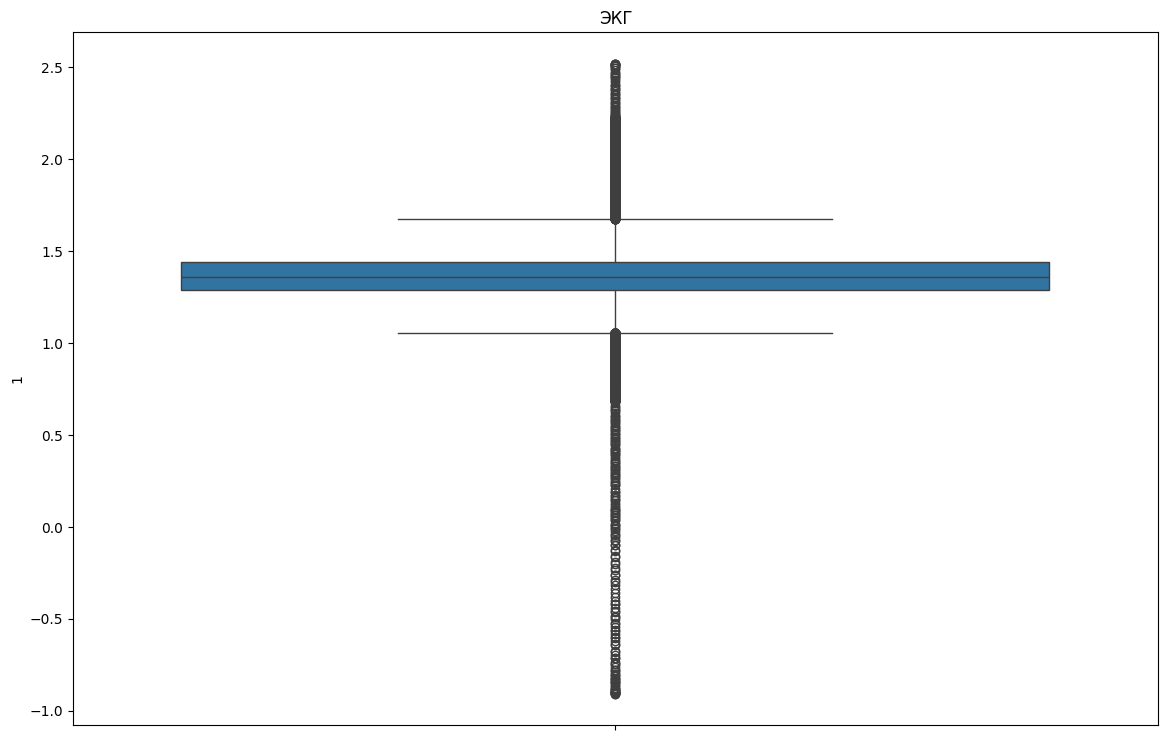

In [40]:
fig = plt.figure(figsize=(14, 9))
ax = sns.boxplot(ecg["1"])
ax.set_title('ЭКГ')

Давайте напишем функцию для автоматического обнаружения выбросов во временном ряду с использованием алгоритма кластеризации из библиотеки scikit-learn: машина векторов поддержки одного класса, она изучает границы распределения (называемые « support ») и, следовательно, может классифицировать любые точки, лежащие за пределами границы, как выбросы.

In [41]:
from sklearn import preprocessing, svm

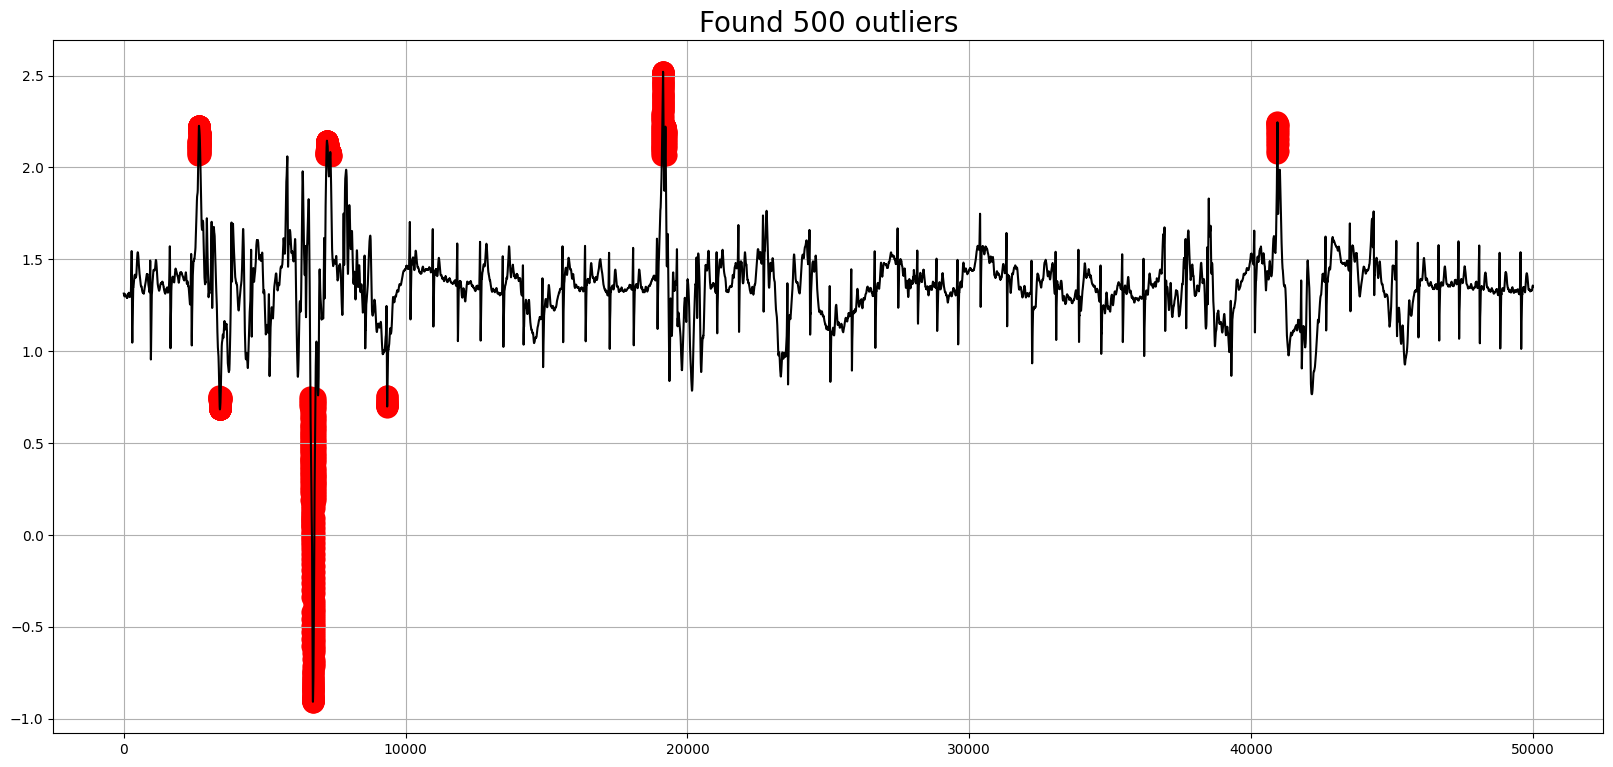

In [42]:
scaler = preprocessing.StandardScaler()
perc = 0.01

local_df = ecg["1"]

ts_scaled = scaler.fit_transform(local_df.values.reshape(-1,1))
model = svm.OneClassSVM(nu=perc, kernel="rbf", gamma=0.01)
model.fit(ts_scaled)
## dtf output
dtf_outliers =local_df.to_frame(name="ts")
dtf_outliers["index"] = range(len(local_df))
dtf_outliers["outlier"] = model.predict(ts_scaled)
dtf_outliers["outlier"] = dtf_outliers["outlier"].apply(lambda
                                                            x: 1 if x==-1 else 0)
## plot
fig, ax = plt.subplots(figsize=(20, 9))
ax.plot(dtf_outliers["index"], dtf_outliers["ts"],
        color="black")
ax.scatter(x=dtf_outliers[dtf_outliers["outlier"]==1]["index"],
           y=dtf_outliers[dtf_outliers["outlier"]==1]['ts'],
           color='red', linewidths=10)
plt.title(f"Found {sum(dtf_outliers['outlier']==1)} outliers", fontdict={'fontsize': 20})
ax.grid(True)
plt.show()

Но что нам делать с выбросами после обнаружения? Здесь нет оптимальной стратегии: прогнозировать временные ряды проще без точек данных, которые значительно отличаются от других наблюдений, но удаление этих точек может глубоко изменить распределение данных. Если вы решили исключить выбросы, наиболее удобный способ их удаления - интерполяция.

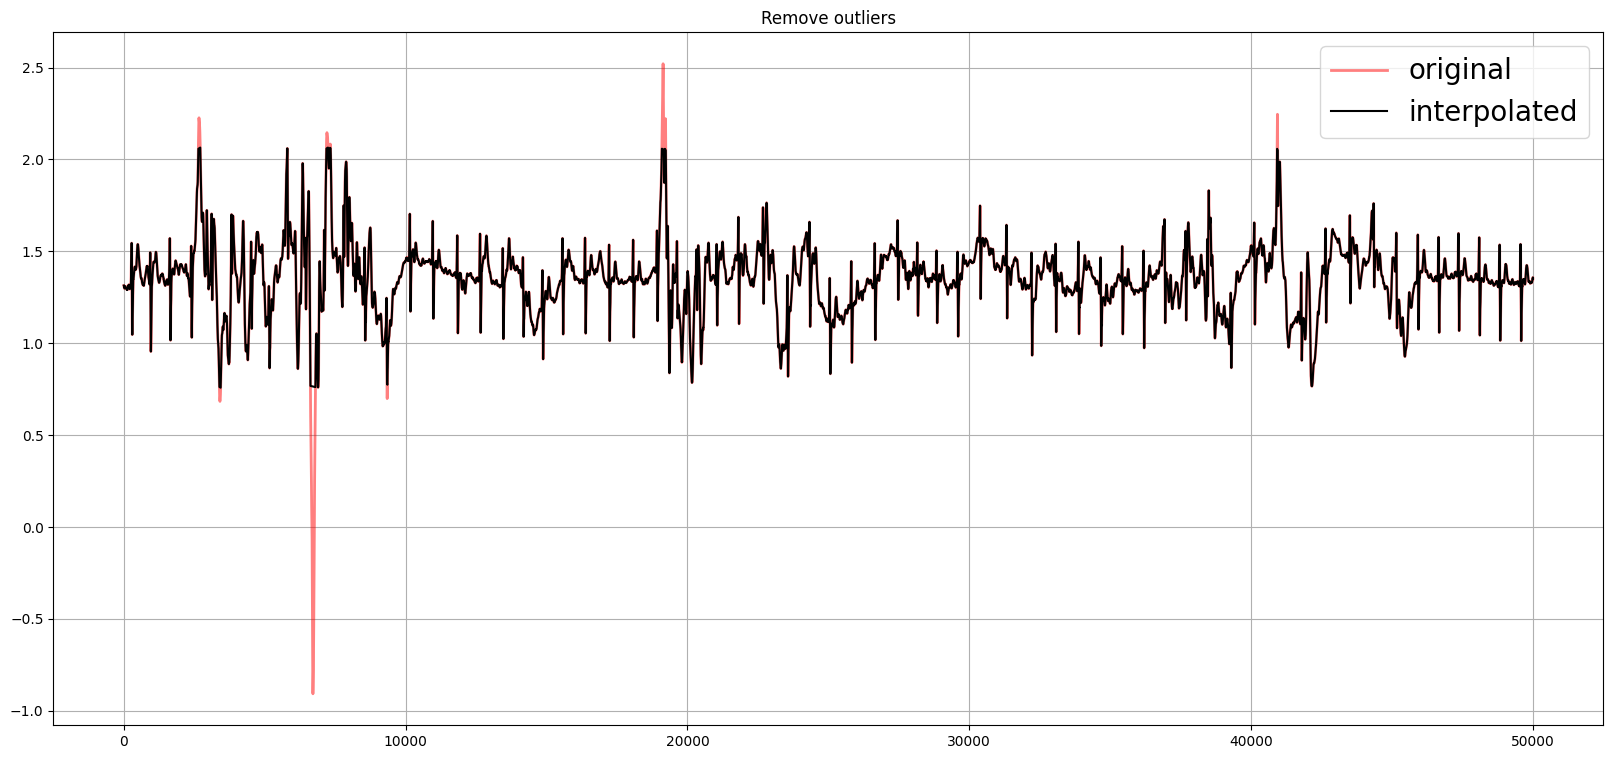

In [43]:
outliers_idx = dtf_outliers[dtf_outliers["outlier"]==1].index

ts_clean = local_df.copy()
ts_clean.loc[outliers_idx] = np.nan
ts_clean = ts_clean.interpolate(method="linear")
ax = local_df.plot(figsize=(20, 9), color="red", alpha=0.5,
             title="Remove outliers", label="original", legend=True, linewidth=2)
ts_clean.plot(ax=ax, grid=True, color="black",
              label="interpolated", legend=True)
plt.legend(fontsize="20")
plt.show()

# Задание №2: Анализ нестационарного ряда и прогнозирование с ARIMA

## Описание
У вас есть временной ряд продаж онлайн-магазина за 200 дней. Ряд нестационарный (имеет тренд и случайный шум).

**Ваша задача:**
* Загрузить и визуализировать ряд
* Проверить стационарность с помощью ADF-теста
* Применить дифференцирование и убедиться, что ряд стал стационарным
* Выбрать оптимальные параметры ARIMA(p,d,q)
* Сделать walk-forward прогноз на тестовом наборе
* Оценить качество прогноза (MAE, RMSE)


In [47]:
import numpy as np
import pandas as pd
np.random.seed(42)

# Генерируем нестационарный ряд
n = 200
trend = np.linspace(50, 250, n)  # Линейный тренд от 50 к 250
noise = np.random.normal(0, 15, n)  # Шум
random_walk = np.cumsum(np.random.normal(0, 5, n))  # Random walk

sales = trend + random_walk + noise

df = pd.DataFrame({'day': np.arange(1, n+1),'sales': sales})
df.set_index('day', inplace=True)
df.head(10)

,sales
day,
1,59.239649
2,53.523920
3,71.733494
4,91.137649
5,58.896579
6,55.212725
7,85.993173
8,77.390457
9,62.417084


2: Визуализация ряда

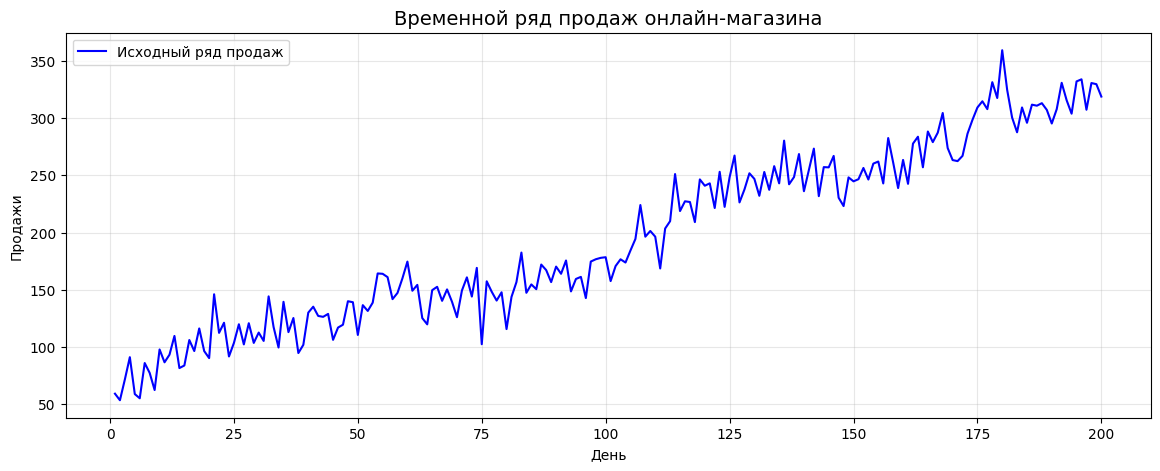

In [48]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['sales'], label='Исходный ряд продаж', color='blue')
plt.title('Временной ряд продаж онлайн-магазина', fontsize=14)
plt.xlabel('День')
plt.ylabel('Продажи')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

3: Проверка стационарности (ADF-тест)

**Тест Дики-Фуллера:**
- H0 (нулевая гипотеза): ряд имеет единичный корень (нестационарен)
- Если p-value < 0.05, мы отклоняем H0 → ряд стационарен
- Если p-value > 0.05, ряд нестационарен

In [49]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(series)

print('--- ADF-тест Дики-Фуллера ---')
print(f'ADF статистика: {result[0]:.6f}')
print(f'p-value: {result[1]:.6f}')
print(f'Критические значения: {result[4]}')

# Интерпретация
if result[1] < 0.05:
    print('p-value < 0.05 → отклоняем H0 → ряд стационарен')
else:
    print('p-value > 0.05 → не отклоняем H0 → ряд нестационарен')

--- ADF-тест Дики-Фуллера ---
ADF статистика: 0.815369
p-value: 0.991880
Критические значения: {'1%': np.float64(-3.4816817173418295), '5%': np.float64(-2.8840418343195267), '10%': np.float64(-2.578770059171598)}
p-value > 0.05 → не отклоняем H0 → ряд нестационарен


4: Дифференцирование

Возьмём первую разность: Δy_t = y_t - y_(t-1)

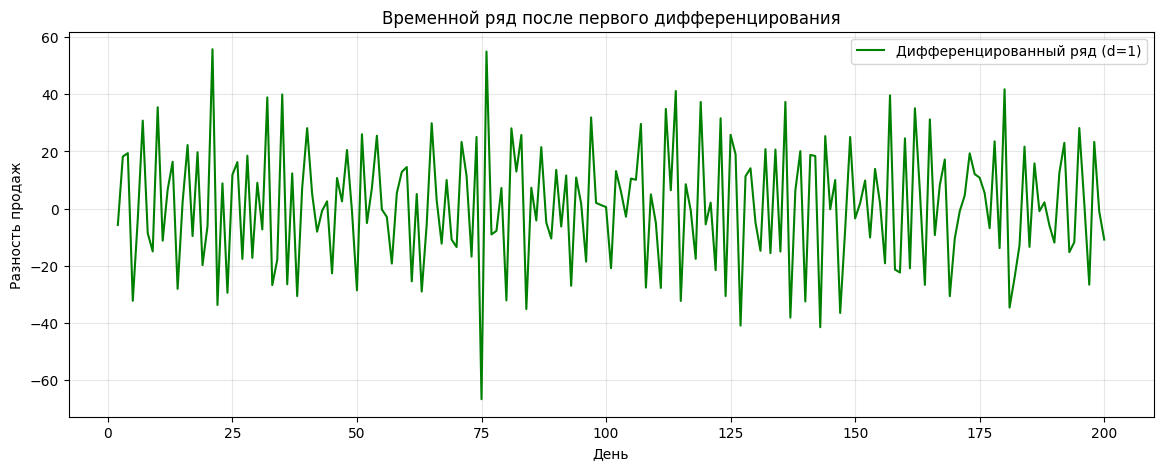

ADF p-value после дифференцирования: 0.000000
Ряд стал стационарным (p-value < 0.05)


In [50]:
# Применить первое дифференцирование (d=1)
df['sales_diff'] = df['sales'].diff()
df_diff = df.dropna().copy()

# Визуализация дифференцированного ряда
plt.figure(figsize=(14, 5))
plt.plot(df_diff.index, df_diff['sales_diff'], label='Дифференцированный ряд (d=1)', color='green')
plt.title('Временной ряд после первого дифференцирования')
plt.xlabel('День')
plt.ylabel('Разность продаж')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Проверка стационарности дифференцированного ряда (опционально)
from statsmodels.tsa.stattools import adfuller
result = adfuller(df_diff['sales_diff'])
print(f'ADF p-value после дифференцирования: {result[1]:.6f}')
if result[1] < 0.05:
    print('Ряд стал стационарным (p-value < 0.05)')
else:
    print('Ряд всё ещё нестационарен, возможно, нужна вторая разность')

5: Проверка стационарности разности

In [51]:
from statsmodels.tsa.stattools import adfuller

def check_stationarity(series, title=''):
    """
    Функция для проверки стационарности временного ряда с помощью ADF-теста
    """
    result = adfuller(series.dropna())  # dropna на случай пропусков
    print(f'--- ADF тест для {title} ---')
    print(f'ADF статистика: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    for key, value in result[4].items():
        print(f'Критическое значение {key}: {value:.3f}')
    
    if result[1] < 0.05:
        print('Вывод: Ряд стационарен (отвергаем H0)')
        return True
    else:
        print('Вывод: Ряд нестационарен (принимаем H0)')
        return False

# Применяем к дифференцированному ряду
check_stationarity(df_diff['sales_diff'], 'разности (d=1)')

--- ADF тест для разности (d=1) ---
ADF статистика: -10.243983
p-value: 0.000000
Критическое значение 1%: -3.465
Критическое значение 5%: -2.877
Критическое значение 10%: -2.575
Вывод: Ряд стационарен (отвергаем H0)


True

6: Выбор параметров ARIMA

Поскольку мы применили d=1, нам нужно выбрать p и q.
Совет: для т.ч. ряда часто подходят небольшие значения, например p=1-5, q=0-3

In [52]:
# Оба варианта)
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

# Вариант 1: Простая модель ARIMA(1,1,1)
model_111 = ARIMA(df['sales'], order=(1,1,1))
fit_111 = model_111.fit()
print("=== ARIMA(1,1,1) ===")
print(fit_111.summary())
print(f"AIC = {fit_111.aic:.2f}\n")

# Вариант 2: Перебор параметров p и q по AIC
p_range = range(0, 6)   # p от 0 до 5
q_range = range(0, 4)   # q от 0 до 3
best_aic = np.inf
best_order = None
best_model = None

print("Перебор комбинаций (p, q) для ARIMA(p,1,q):")
for p in p_range:
    for q in q_range:
        try:
            model = ARIMA(df['sales'], order=(p,1,q))
            fit = model.fit()
            aic = fit.aic
            print(f"p={p}, q={q} : AIC = {aic:.2f}")
            if aic < best_aic:
                best_aic = aic
                best_order = (p,1,q)
                best_model = fit
        except:
            print(f"p={p}, q={q} : модель не сошлась")
            continue

print(f"\nЛучшая модель: ARIMA{best_order} с AIC = {best_aic:.2f}")
print(best_model.summary())

=== ARIMA(1,1,1) ===
                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                  200
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -850.051
Date:                Fri, 05 Jun 2026   AIC                           1706.101
Time:                        18:42:22   BIC                           1715.981
Sample:                             0   HQIC                          1710.100
                                - 200                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0357      0.106     -0.336      0.737      -0.244       0.173
ma.L1         -0.6487      0.081     -8.000      0.000      -0.808      -0.490
sigma2       299.5625     29.93

7: Walk-Forward Validation и прогнозирование

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Разделим на обучающую (первые 180 дней) и тестовую (последние 20 дней)
train = df['sales'].iloc[:-20].copy()
test = df['sales'].iloc[-20:].copy()

# Определите оптимальные параметры, найденные ранее (например, из перебора AIC)
# Если вы не сохранили best_order, используйте (1,1,1) или (2,1,0) как запасной вариант
# Здесь для примера возьмём (2,1,0) – часто подходит для рядов с трендом
p, d, q = 2, 1, 0

# Walk-forward прогнозирование
history = list(train)
predictions = []

print("Walk-forward прогноз по дням:")
for t in range(len(test)):
    model = ARIMA(history, order=(p, d, q))
    model_fit = model.fit()
    yhat = model_fit.forecast()[0]
    predictions.append(yhat)
    history.append(test.iloc[t])  # добавляем реальное значение для следующего шага
    print(f"День {test.index[t]}: факт = {test.iloc[t]:.2f}, прогноз = {yhat:.2f}")

Walk-forward прогноз по дням:
День 181: факт = 324.59, прогноз = 337.02
День 182: факт = 300.36, прогноз = 334.49
День 183: факт = 287.54, прогноз = 325.98
День 184: факт = 309.22, прогноз = 301.90
День 185: факт = 295.84, прогноз = 299.68
День 186: факт = 311.66, прогноз = 297.92
День 187: факт = 310.76, прогноз = 305.74
День 188: факт = 312.95, прогноз = 306.95
День 189: факт = 307.10, прогноз = 311.87
День 190: факт = 295.20, прогноз = 310.04
День 191: факт = 307.74, прогноз = 303.98
День 192: факт = 330.75, прогноз = 303.42
День 193: факт = 315.52, прогноз = 313.44
День 194: факт = 303.78, прогноз = 318.32
День 195: факт = 331.97, прогноз = 315.07
День 196: факт = 333.81, прогноз = 318.26
День 197: факт = 307.21, прогноз = 324.70
День 198: факт = 330.55, прогноз = 322.72
День 199: факт = 329.55, прогноз = 324.19
День 200: факт = 318.72, прогноз = 323.29


8: Визуализация + метрики


--- Качество прогноза на тестовой выборке (20 дней) ---
MAE  = 12.80
RMSE = 16.25


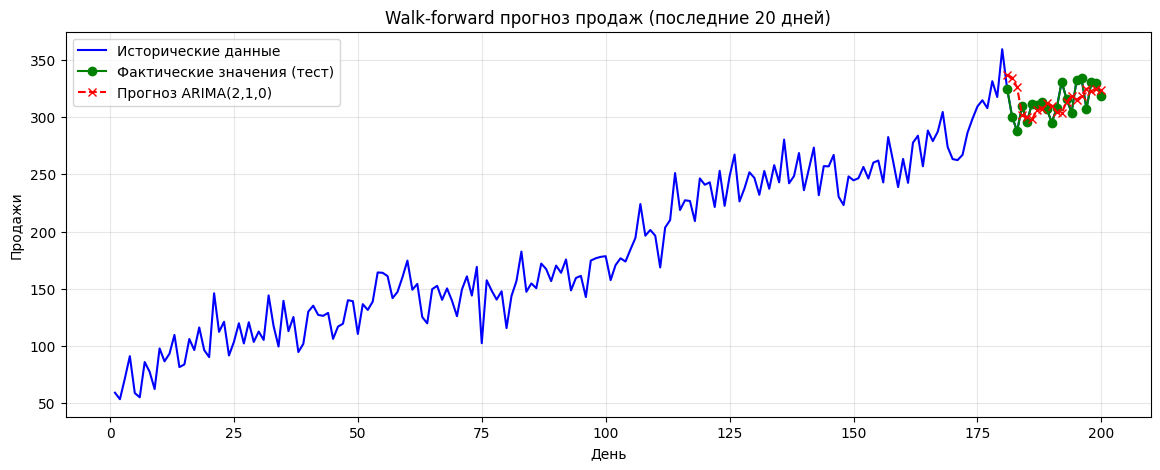

In [54]:
# Оценка качества
mae = mean_absolute_error(test, predictions)
rmse = np.sqrt(mean_squared_error(test, predictions))

print("\n--- Качество прогноза на тестовой выборке (20 дней) ---")
print(f"MAE  = {mae:.2f}")
print(f"RMSE = {rmse:.2f}")

# Визуализация
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['sales'], label='Исторические данные', color='blue')
plt.plot(test.index, test, label='Фактические значения (тест)', color='green', marker='o')
plt.plot(test.index, predictions, label=f'Прогноз ARIMA({p},{d},{q})', color='red', linestyle='--', marker='x')
plt.title('Walk-forward прогноз продаж (последние 20 дней)')
plt.xlabel('День')
plt.ylabel('Продажи')
plt.legend()
plt.grid(alpha=0.3)
plt.show()